# (노트) Fashion_MNIST  

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

## import

In [46]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [47]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [268]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+ s + ';}')

## 경사하강법과 확률적경사하강법

`-` 10개의 샘플이 있다고 하자. 

### ver1: 모든 샘플을 사용하여 slope계산

(epoch1) $loss=\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$

(epoch2) $loss=\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$

...

### ver2: 하나의 샘플만 사용하여 slope계산 

(epoch1) 
- $loss=(y_1-\beta_0-\beta_1x_1)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=(y_2-\beta_0-\beta_1x_1)^2 \quad \to \quad slope \quad \to \quad update$
- ...
- $loss=(y_{10}-\beta_0-\beta_1x_{10})^2 \quad \to \quad slope \quad \to \quad update$

(epoch2) 
- $loss=(y_1-\beta_0-\beta_1x_1)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=(y_2-\beta_0-\beta_1x_1)^2 \quad \to \quad slope \quad \to \quad update$
- ...
- $loss=(y_{10}-\beta_0-\beta_1x_{10})^2 \quad \to \quad slope \quad \to \quad update$

...

### ver3: $m(\leq n)$개의 샘플만 사용하여 slope계산

$m=3$이라고 하자. 

(epoch1) 
- $loss=\sum_{i=1}^{3}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=\sum_{i=4}^{6}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=\sum_{i=7}^{9}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=(y_{10}-\beta_0-\beta_1x_{10})^2 \quad \to \quad slope \quad \to \quad update$

(epoch2) 
- $loss=\sum_{i=1}^{3}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=\sum_{i=4}^{6}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=\sum_{i=7}^{9}(y_i-\beta_0-\beta_1x_i)^2 \quad \to \quad slope \quad \to \quad update$
- $loss=(y_{10}-\beta_0-\beta_1x_{10})^2 \quad \to \quad slope \quad \to \quad update$

...

### 용어의 정리 

#### 옛날 (좀 더 엄밀)

`-` ver1: gradient descent, batch gradient descent 


`-` ver2: stochastic gradient descent

`-` ver3: mini-batch gradient descent, mini-batch stochastic gradient descent

#### 요즘 

`-` ver1: gradient descent


`-` ver2: stochastic gradient descent with batch size = 1 

`-` ver3: stochastic gradient descent 
- https://www.deeplearningbook.org/contents/optimization.html, 알고리즘 8-1 참고. 

note: 이렇게 많이 쓰는 이유? ver1,2는 사실상 없는 방법이므로

### ver1,2,3 이외에 좀 더 지저분한 것들이 있다. 

`-` ver2,3에서 샘플을 셔플할 수도 있다. 

`-` ver3에서 일부 샘플이 학습에 참여 안하는 버전도 있다. 

`-` 개인적 생각: 너무 더럽다 그냥.. (딱히 엄청난 효과가 있는것도 아니고 각 방법마다 이론이 있는것도 아님) 

### Discussion 

`-` 핵심개념 
- **메모리사용량: ver1 > ver3 > ver2**
- 계산속도: ver1 > ver3 > ver2 
- local-min에 갇힘: ver1 > ver3 > ver2

`-` 본질: GPU 메모리가 한정되어 있어서 ver1을 쓰지는 못한다. 

`-` 틀리진 않지만 어색한 블로그 정리 내용들 
- 확률적 경사하강법은 경사하강법과 비교하면 local-min에 갇히지 않는다. -> 경사하강법 자체가 원래 로칼민에 잘 갇힌다. 확률적 경사하강법은 로칼민에 갇히더라고 우연히 빠져나올 수 있는 기회가 좀 더 있을뿐이다. 
- 경사하강법은 종종 국소최소점에 갇히는 문제가 있다. 이를 해결하기 위해서 등장한 방법이 확률적 경사하강법이다. -> 그다지 틀린만은 아닌데 본질은 그게 아님. 
- 경사하강법은 계산시간이 오래걸린다. 계산을 빠르게 하기 위해서 등장한 방법이 확률적 경사하강법이다. -> 맞긴한데 본질이 그게 아님. 


## fashion_mnist 모듈 

### tf.keras.datasets.fashion_mnist.load_data()

In [48]:
tf.keras.datasets.fashion_mnist # 이거 모듈임 

<module 'tensorflow.keras.datasets.fashion_mnist' from '/home/cgb3/anaconda3/envs/tfgpu/lib/python3.9/site-packages/tensorflow/keras/datasets/fashion_mnist/__init__.py'>

In [49]:
type(tf.keras.datasets.fashion_mnist.load_data) # 함수이다. 

function

In [50]:
tf.keras.datasets.fashion_mnist.load_data??
## return (x_train, y_train), (x_test, y_test) 이것이 리턴된다. 

Signature: tf.keras.datasets.fashion_mnist.load_data()
Source:   
@keras_export('keras.datasets.fashion_mnist.load_data')
def load_data():
  """Loads the Fashion-MNIST dataset.

  This is a dataset of 60,000 28x28 grayscale images of 10 fashion categories,
  along with a test set of 10,000 images. This dataset can be used as
  a drop-in replacement for MNIST. The class labels are:

  | Label | Description |
  |:-----:|-------------|
  |   0   | T-shirt/top |
  |   1   | Trouser     |
  |   2   | Pullover    |
  |   3   | Dress       |
  |   4   | Coat        |
  |   5   | Sandal      |
  |   6   | Shirt       |
  |   7   | Sneaker     |
  |   8   | Bag         |
  |   9   | Ankle boot  |

  Returns:
      Tuple of Numpy arrays: `(x_train, y_train), (x_test, y_test)`.

      **x_train, x_test**: uint8 arrays of grayscale image data with shape
        (num_samples, 28, 28).

      **y_train, y_test**: uint8 arrays of labels (integers in range 0-9)
        with shape (num_samples,).

  Li

### 데이터생성 및 탐색

`-` 데이터생성 

In [51]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

`-` 타입조사

In [52]:
type(x_train),type(y_train),type(x_test),type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

`-` shape 조사 

In [53]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [54]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

`-` X는 뭐지..? 

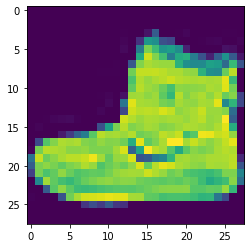

In [55]:
plt.imshow(x_train[0])

- 신발..?

In [56]:
y_train[0] # 신발=9 

9

In [57]:
np.where(y_train==9)

(array([    0,    11,    15, ..., 59932, 59970, 59978]),)

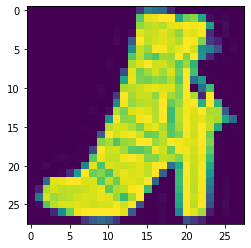

In [58]:
plt.imshow(x_train[11])

- 신발!

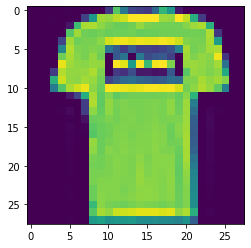

In [59]:
plt.imshow(x_train[1])

In [60]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

## 예제1

`-` y=0,1에 대응하는 이미지만 정리하자. (우리가 배운건 로지스틱이니깐) 

(예비학습코드)

In [227]:
np.array([True,False,True,False,]) | np.array([True,True,False,False])

array([ True,  True,  True, False])

In [228]:
X = x_train[(y_train==1) | (y_train==0)].reshape(-1,28*28)
y = y_train[(y_train==1) | (y_train==0)].reshape(-1,1)
XX = x_test[(y_test==1) | (y_test==0)].reshape(-1,28*28)
yy = y_test[(y_test==1) | (y_test==0)].reshape(-1,1)

In [229]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='sgd',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=500,batch_size=12000) 

Epoch 1/500
1/1 [==============================] - 0s 87ms/step - loss: 23.6410
Epoch 2/500
1/1 [==============================] - 0s 4ms/step - loss: 2048.4263
Epoch 3/500
1/1 [==============================] - 0s 3ms/step - loss: 10669.9609
Epoch 4/500
1/1 [==============================] - 0s 2ms/step - loss: 1531.8008
Epoch 5/500
1/1 [==============================] - 0s 2ms/step - loss: 555.8586
Epoch 6/500
1/1 [==============================] - 0s 2ms/step - loss: 214.4530
Epoch 7/500
1/1 [==============================] - 0s 2ms/step - loss: 180.1079
Epoch 8/500
1/1 [==============================] - 0s 2ms/step - loss: 167.2023
Epoch 9/500
1/1 [==============================] - 0s 2ms/step - loss: 156.5932
Epoch 10/500
1/1 [==============================] - 0s 2ms/step - loss: 146.5200
Epoch 11/500
1/1 [==============================] - 0s 2ms/step - loss: 137.1044
Epoch 12/500
1/1 [==============================] - 0s 2ms/step - loss: 128.0815
Epoch 13/500
1/1 [===============

In [230]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9876666666666667

In [231]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.9845

### **풀이1: 은닉층을 포함한 신경망**

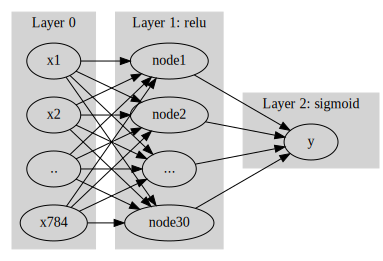

In [271]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "y"
    "node2" -> "y"
    "..." -> "y"
    "node30" -> "y"
    label = "Layer 2: sigmoid"
}
''')

In [ ]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='sgd',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 109ms/step - loss: 32.5990
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 6041.9619
Epoch 3/100
1/1 [==============================] - 0s 3ms/step - loss: 45273.3086
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 0.9923
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 0.8082
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 0.7354
Epoch 7/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6921
Epoch 8/100
1/1 [==============================] - 0s 3ms/step - loss: 0.6903
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6857
Epoch 10/100
1/1 [==============================] - 0s 3ms/step - loss: 0.6701
Epoch 11/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6118
Epoch 12/100
1/1 [==============================] - 0s 2ms/step - loss: 0.5392
Epoch 13/100
1/1 [==============================] -

- 에폭100말고 좀더 기회주면 잘맞추긴하는데 이정도에서 정리하자. 

In [233]:
np.mean(y == (net(X)>0.5)) 

0.6118333333333333

In [234]:
np.mean(yy== (net(XX)> 0.5)) 

0.6285

### **풀이2: 옵티마이저 개선**

In [235]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 127ms/step - loss: 32.5990
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 62.4860
Epoch 3/100
1/1 [==============================] - 0s 3ms/step - loss: 22.2786
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 5.6635
Epoch 5/100
1/1 [==============================] - 0s 3ms/step - loss: 8.1104
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 12.8681
Epoch 7/100
1/1 [==============================] - 0s 2ms/step - loss: 11.2444
Epoch 8/100
1/1 [==============================] - 0s 3ms/step - loss: 7.4869
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 5.1798
Epoch 10/100
1/1 [==============================] - 0s 2ms/step - loss: 4.3305
Epoch 11/100
1/1 [==============================] - 0s 3ms/step - loss: 4.2611
Epoch 12/100
1/1 [==============================] - 0s 2ms/step - loss: 4.4695
Epoch 13/100
1/1 [==============================] - 0s

In [236]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9851666666666666

In [237]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.979

### **풀이3: 컴파일시 metrics=['accuracy'] 추가**

`-` 출력보기가 쪼끔 여럽다..

In [238]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy, metrics=['accuracy'])
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 131ms/step - loss: 32.5990 - accuracy: 0.4780
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 62.4860 - accuracy: 0.5049
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 22.2786 - accuracy: 0.6696
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 5.6635 - accuracy: 0.9117
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 8.1104 - accuracy: 0.8633
Epoch 6/100
1/1 [==============================] - 0s 3ms/step - loss: 12.8681 - accuracy: 0.8176
Epoch 7/100
1/1 [==============================] - 0s 3ms/step - loss: 11.2444 - accuracy: 0.8455
Epoch 8/100
1/1 [==============================] - 0s 3ms/step - loss: 7.4869 - accuracy: 0.8931
Epoch 9/100
1/1 [==============================] - 0s 3ms/step - loss: 5.1798 - accuracy: 0.9256
Epoch 10/100
1/1 [==============================] - 0s 3ms/step - loss: 4.3305 - accuracy: 0.9439
Epoch 11/100
1/1 [====

In [239]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9851666666666666

In [240]:
net.evaluate(X,y)

375/375 [==============================] - 0s 396us/step - loss: 0.6171 - accuracy: 0.9852


[0.6171350479125977, 0.9851666688919067]

In [241]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.979

In [242]:
net.evaluate(XX,yy)

63/63 [==============================] - 0s 637us/step - loss: 0.8388 - accuracy: 0.9790


[0.8388248085975647, 0.9789999723434448]

### 풀이4: 확률적경사하강법 이용

In [243]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy, metrics=['accuracy'])
net.fit(X,y,epochs=10,batch_size=1200) 

Epoch 1/10
10/10 [==============================] - 0s 829us/step - loss: 26.3620 - accuracy: 0.6745
Epoch 2/10
10/10 [==============================] - 0s 819us/step - loss: 4.8062 - accuracy: 0.9530
Epoch 3/10
10/10 [==============================] - 0s 688us/step - loss: 1.7266 - accuracy: 0.9690
Epoch 4/10
10/10 [==============================] - 0s 718us/step - loss: 1.2493 - accuracy: 0.9779
Epoch 5/10
10/10 [==============================] - 0s 701us/step - loss: 1.0800 - accuracy: 0.9808
Epoch 6/10
10/10 [==============================] - 0s 696us/step - loss: 0.9924 - accuracy: 0.9810
Epoch 7/10
10/10 [==============================] - 0s 682us/step - loss: 0.7841 - accuracy: 0.9827
Epoch 8/10
10/10 [==============================] - 0s 957us/step - loss: 0.7067 - accuracy: 0.9833
Epoch 9/10
10/10 [==============================] - 0s 748us/step - loss: 0.6977 - accuracy: 0.9828
Epoch 10/10
10/10 [==============================] - 0s 630us/step - loss: 0.6387 - accuracy: 0.983

In [244]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9845833333333334

In [245]:
net.evaluate(X,y)

375/375 [==============================] - 0s 392us/step - loss: 0.6281 - accuracy: 0.9846


[0.6280558109283447, 0.98458331823349]

In [246]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.9815

In [247]:
net.evaluate(XX,yy)

63/63 [==============================] - 0s 591us/step - loss: 0.8386 - accuracy: 0.9815


[0.8385966420173645, 0.9815000295639038]

### yhat을 만드는 과정 복습 

In [248]:
## 1
net = tf.keras.Sequential()
## 2 
net.add(tf.keras.layers.Dense(30))
net.add(tf.keras.layers.Activation(tf.nn.relu))
net.add(tf.keras.layers.Dense(1))
net.add(tf.keras.layers.Activation(tf.nn.sigmoid))
## 3 
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy,metrics=['accuracy']) 
## 4 
net.fit(X,y,epochs=500,verbose=0,batch_size=12000)

In [249]:
l1,a1,l2,a2 = net.layers

In [250]:
l2(a1(l1(X)))

<tf.Tensor: shape=(12000, 1), dtype=float32, numpy=
array([[-471.0625  ],
       [ -20.220974],
       [ -74.186874],
       ...,
       [ 172.49263 ],
       [  44.50918 ],
       [-131.57347 ]], dtype=float32)>

In [251]:
a2(l2(a1(l1(X))))

<tf.Tensor: shape=(12000, 1), dtype=float32, numpy=
array([[0.0000000e+00],
       [1.6525041e-09],
       [6.0401793e-33],
       ...,
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00]], dtype=float32)>

In [252]:
np.exp(-213.75027)

1.4771929751182097e-93

## 예제2

`-` 다중분류문제 

In [253]:
X = x_train.reshape(-1,28*28)
y = y_train.reshape(-1,1) 
XX = x_test.reshape(-1,28*28)
yy = y_test.reshape(-1,1) 

In [254]:
y

array([[9],
       [0],
       [0],
       ...,
       [3],
       [0],
       [5]], dtype=uint8)

- $y=0,1,2\dots,9$

`-` 이거 뭐지? 에러텀을 뭘로 잡아야 $y$를 얻을수 있지? 

`-` 만약에 아래와 같이 $y$를 바꾼다면?

In [255]:
tf.keras.utils.to_categorical(y)

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

- 각각 따로 추정한뒤에 적당히 합치면 될 것 같다. 

$$\hat{\pi}_{0}=\frac{\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}{1+\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}$$

$$\hat{\pi}_{1}=\frac{\exp(-{\bf X}{\bf W}_1 +{\bf b}_1)}{1+\exp(-{\bf X}{\bf W}_1 +{\bf b}_1)}$$

$$\hat{\pi}_{0}=\frac{\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}{1+\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}$$

$$\hat{\pi}_{0}=\frac{\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}{1+\exp(-{\bf X}{\bf W}_0 +{\bf b}_0)}$$

`-` y와 yy를 원핫인코딩으로 변환 

In [256]:
y=tf.keras.utils.to_categorical(y)
yy=tf.keras.utils.to_categorical(yy)

### 풀이1: 아까 예제1 정도의 모델로!

In [257]:
X.shape

(60000, 784)

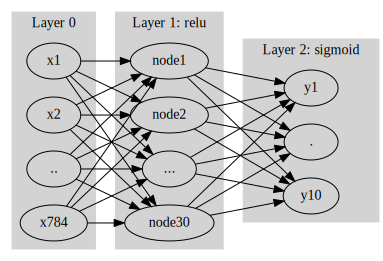

In [286]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;

    "node1" -> "y10"
    "node2" -> "y10"
    "..." -> "y10"
    "node30" -> "y10"
    
    "node1" -> "y1"
    "node2" -> "y1"
    "..." -> "y1"
    "node30" -> "y1"
    
    "node1" -> "."
    "node2" -> "."
    "..." -> "."
    "node30" -> "."
    
    label = "Layer 2: sigmoid"
}
''')

In [258]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(10,activation='softmax'))
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=100,batch_size=600) 

Epoch 1/100
100/100 [==============================] - 0s 669us/step - loss: 36.8850 - accuracy: 0.4311
Epoch 2/100
100/100 [==============================] - 0s 653us/step - loss: 1.9780 - accuracy: 0.4507
Epoch 3/100
100/100 [==============================] - 0s 593us/step - loss: 1.6775 - accuracy: 0.4908
Epoch 4/100
100/100 [==============================] - 0s 603us/step - loss: 1.5314 - accuracy: 0.5260
Epoch 5/100
100/100 [==============================] - 0s 674us/step - loss: 1.4089 - accuracy: 0.5570
Epoch 6/100
100/100 [==============================] - 0s 621us/step - loss: 1.2846 - accuracy: 0.5722
Epoch 7/100
100/100 [==============================] - 0s 665us/step - loss: 1.2188 - accuracy: 0.5873
Epoch 8/100
100/100 [==============================] - 0s 661us/step - loss: 1.1554 - accuracy: 0.5997
Epoch 9/100
100/100 [==============================] - 0s 660us/step - loss: 1.1029 - accuracy: 0.6113
Epoch 10/100
100/100 [==============================] - 0s 674us/step - 

In [259]:
net.evaluate(XX,yy)

313/313 [==============================] - 0s 654us/step - loss: 0.5638 - accuracy: 0.8229


[0.5638093948364258, 0.8228999972343445]

### 풀이2: 더 깊은 신경망 

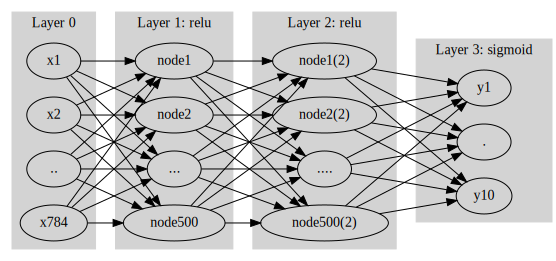

In [295]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node500"
    "x2" -> "node500"
    ".." -> "node500"
    "x784" -> "node500"


    label = "Layer 1: relu"
}

subgraph cluster_3{
    style=filled;
    color=lightgrey;

    "node1" -> "node1(2)"
    "node2" -> "node1(2)"
    "..." -> "node1(2)"
    "node500" -> "node1(2)"

    "node1" -> "node2(2)"
    "node2" -> "node2(2)"
    "..." -> "node2(2)"
    "node500" -> "node2(2)"
    
    "node1" -> "...."
    "node2" -> "...."
    "..." -> "...."
    "node500" -> "...."
    
    "node1" -> "node500(2)"
    "node2" -> "node500(2)"
    "..." -> "node500(2)"
    "node500" -> "node500(2)"

    
    label = "Layer 2: relu"
}

subgraph cluster_4{
    style=filled;
    color=lightgrey;

    "node1(2)" -> "y10"
    "node2(2)" -> "y10"
    "...." -> "y10"
    "node500(2)" -> "y10"
    
    "node1(2)" -> "y1"
    "node2(2)" -> "y1"
    "...." -> "y1"
    "node500(2)" -> "y1"
    
    "node1(2)" -> "."
    "node2(2)" -> "."
    "...." -> "."
    "node500(2)" -> "."
    
    label = "Layer 3: sigmoid"
}
''')

In [296]:
X.shape

(60000, 784)

In [297]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(500,activation='relu'))
net.add(tf.keras.layers.Dense(500,activation='relu'))
net.add(tf.keras.layers.Dense(10,activation='softmax'))
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=100,batch_size=600) 

Epoch 1/100
100/100 [==============================] - 0s 1ms/step - loss: 38.0608 - accuracy: 0.6105
Epoch 2/100
100/100 [==============================] - 0s 1ms/step - loss: 1.3630 - accuracy: 0.8031
Epoch 3/100
100/100 [==============================] - 0s 1ms/step - loss: 0.8293 - accuracy: 0.8304
Epoch 4/100
100/100 [==============================] - 0s 1ms/step - loss: 0.6388 - accuracy: 0.8453
Epoch 5/100
100/100 [==============================] - 0s 1ms/step - loss: 0.5213 - accuracy: 0.8550
Epoch 6/100
100/100 [==============================] - 0s 1ms/step - loss: 0.4296 - accuracy: 0.8687
Epoch 7/100
100/100 [==============================] - 0s 1ms/step - loss: 0.4009 - accuracy: 0.8742
Epoch 8/100
100/100 [==============================] - 0s 1ms/step - loss: 0.3384 - accuracy: 0.8863
Epoch 9/100
100/100 [==============================] - 0s 1ms/step - loss: 0.3313 - accuracy: 0.8870
Epoch 10/100
100/100 [==============================] - 0s 1ms/step - loss: 0.3008 - accur

In [298]:
net.evaluate(XX,yy)

313/313 [==============================] - 0s 642us/step - loss: 0.6214 - accuracy: 0.8755


[0.6214433312416077, 0.8755000233650208]

`-` 더 이상은 힘들어 보인다. 

### 풀이3: CNN

In [ ]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Convolution2D(5,(5,5),activation='relu'))
net.add(tf.keras.
net.add(tf.keras.layers.Dense(50,activation='relu'))
net.add(tf.keras.layers.Dense(10,activation='softmax'))
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=100,batch_size=600) 

Init signature:
tf.keras.layers.Conv2D(
    filters,
    kernel_size,
    strides=(1, 1),
    padding='valid',
    data_format=None,
    dilation_rate=(1, 1),
    groups=1,
    activation=None,
    use_bias=True,
    kernel_initializer='glorot_uniform',
    bias_initializer='zeros',
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    **kwargs,
)
Docstring:     
2D convolution layer (e.g. spatial convolution over images).

This layer creates a convolution kernel that is convolved
with the layer input to produce a tensor of
outputs. If `use_bias` is True,
a bias vector is created and added to the outputs. Finally, if
`activation` is not `None`, it is applied to the outputs as well.

When using this layer as the first layer in a model,
provide the keyword argument `input_shape`
(tuple of integers, does not include the sample axis),
e.g. `input_shape=(128, 128, 3)` for 128x128 RGB pictures
in `data

In [191]:
id(tf.keras.layers.Convolution2D)

94251394515408

In [187]:
id(tf.keras.layers.Conv2D)

94251394515408